In [1]:
!pip install shap lime -q

In [2]:
import os, re, time, random, warnings, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, pipeline
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix
import shap
from lime.lime_text import LimeTextExplainer

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory/1e9, 1), 'GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 1. Data Preparation

In [3]:
TRAIN_SIZE = 6000
VAL_SIZE   = 1000
TEST_SIZE  = 1000
MODEL_NAME = 'distilbert-base-uncased'
MAX_LEN    = 128
SAVE_PATH  = '/kaggle/working/saved_model'

dataset   = load_dataset('fancyzhx/amazon_polarity')
train_raw = dataset['train'].shuffle(seed=42)
test_raw  = dataset['test'].shuffle(seed=42)

train_data = train_raw.select(range(TRAIN_SIZE))
val_data   = train_raw.select(range(TRAIN_SIZE, TRAIN_SIZE + VAL_SIZE))
test_data  = test_raw.select(range(TEST_SIZE))

print(f'Train: {len(train_data)} | Val: {len(val_data)} | Test: {len(test_data)}')

README.md: 0.00B [00:00, ?B/s]

amazon_polarity/train-00000-of-00004.par(…):   0%|          | 0.00/260M [00:00<?, ?B/s]

amazon_polarity/train-00001-of-00004.par(…):   0%|          | 0.00/258M [00:00<?, ?B/s]

amazon_polarity/train-00002-of-00004.par(…):   0%|          | 0.00/255M [00:00<?, ?B/s]

amazon_polarity/train-00003-of-00004.par(…):   0%|          | 0.00/254M [00:00<?, ?B/s]

amazon_polarity/test-00000-of-00001.parq(…):   0%|          | 0.00/117M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3600000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/400000 [00:00<?, ? examples/s]

Train: 6000 | Val: 1000 | Test: 1000


In [4]:
def clean(text):
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^\x00-\x7F]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def preprocess(ex):
    ex['text'] = clean(ex['title'] + ' ' + ex['content'])
    return ex

train_data = train_data.map(preprocess)
val_data   = val_data.map(preprocess)
test_data  = test_data.map(preprocess)

print('Sample:', train_data[0]['text'][:150])

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Sample: Anyone who likes this better than the Pekinpah is a moron. All the pretty people in this film. Even the Rudy character played by Michael Madsen. This 


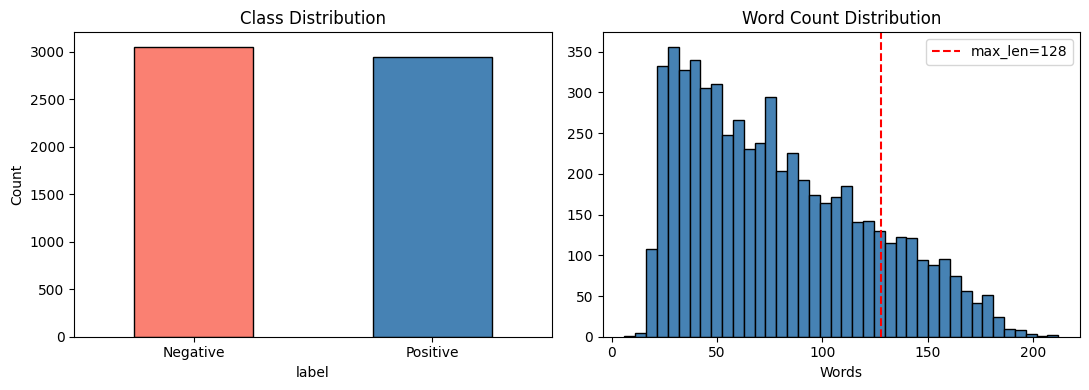

In [5]:
df = train_data.to_pandas()
df['wc'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df['label'].value_counts().sort_index().plot(kind='bar', ax=axes[0],
    color=['salmon','steelblue'], edgecolor='black')
axes[0].set_title('Class Distribution')
axes[0].set_xticklabels(['Negative','Positive'], rotation=0)
axes[0].set_ylabel('Count')

axes[1].hist(df['wc'].clip(upper=250), bins=40, color='steelblue', edgecolor='black')
axes[1].axvline(MAX_LEN, color='red', linestyle='--', label=f'max_len={MAX_LEN}')
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Words')
axes[1].legend()

plt.tight_layout()
plt.savefig('/kaggle/working/eda.png', dpi=120)
plt.show()

## 2. Tokenization

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(batch['text'], padding='max_length', truncation=True, max_length=MAX_LEN)

train_tok = train_data.map(tokenize, batched=True, batch_size=512)
val_tok   = val_data.map(tokenize,   batched=True, batch_size=512)
test_tok  = test_data.map(tokenize,  batched=True, batch_size=512)

cols = ['input_ids', 'attention_mask', 'label']
for d in [train_tok, val_tok, test_tok]:
    d.set_format(type='torch', columns=cols)

print('Done. Shape:', train_tok[0]['input_ids'].shape)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/6000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Done. Shape: torch.Size([128])


## 3. Model & Training

In [7]:
gc.collect()
torch.cuda.empty_cache()

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=2,
    id2label={0:'NEGATIVE', 1:'POSITIVE'},
    label2id={'NEGATIVE':0, 'POSITIVE':1}
).to(DEVICE)

print('Parameters:', f"{sum(p.numel() for p in model.parameters()):,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters: 66,955,010


In [8]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    if isinstance(logits, tuple):
        logits = logits[0]
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': accuracy_score(labels, preds),
        'f1': f1_score(labels, preds)
    }

args = TrainingArguments(
    output_dir='/kaggle/working/checkpoints',
    num_train_epochs=3,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=1,
    eval_accumulation_steps=8,
    learning_rate=2e-5,
    warmup_steps=500,
    weight_decay=0.01,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    fp16=torch.cuda.is_available(),
    gradient_checkpointing=True,
    seed=42,
    report_to='none',
    logging_steps=200,
    dataloader_num_workers=2,
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_tok,
    eval_dataset=val_tok,
    compute_metrics=compute_metrics,
)

trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,No log,1.312090,0.786000,0.778468
2,No log,0.493030,0.905000,0.901145
3,1.076766,0.432891,0.921000,0.919634


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=282, training_loss=0.8857121569045047, metrics={'train_runtime': 144.6306, 'train_samples_per_second': 124.455, 'train_steps_per_second': 1.95, 'total_flos': 596103293952000.0, 'train_loss': 0.8857121569045047, 'epoch': 3.0})

## 4. Evaluation

              precision    recall  f1-score   support

    Negative       0.93      0.92      0.92       487
    Positive       0.93      0.93      0.93       513

    accuracy                           0.93      1000
   macro avg       0.93      0.93      0.93      1000
weighted avg       0.93      0.93      0.93      1000



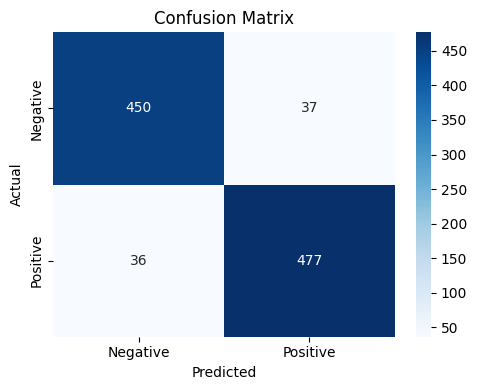

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved.


In [9]:
gc.collect()
torch.cuda.empty_cache()

results = trainer.predict(test_tok)
logits  = results.predictions
if isinstance(logits, tuple):
    logits = logits[0]

y_pred = np.argmax(logits, axis=-1)
y_true = results.label_ids

print(classification_report(y_true, y_pred, target_names=['Negative','Positive']))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=120)
plt.show()

trainer.save_model(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print('Model saved.')

## 5. Attention Analysis

In [10]:
# free training model, load fresh with attentions
del model
gc.collect()
torch.cuda.empty_cache()

attn_model = AutoModelForSequenceClassification.from_pretrained(
    SAVE_PATH, output_attentions=True
).to(DEVICE)
attn_model.eval()

def get_attentions(text):
    inp = tokenizer(text, return_tensors='pt', truncation=True, max_length=MAX_LEN).to(DEVICE)
    with torch.no_grad():
        out = attn_model(**inp)
    n      = inp['attention_mask'][0].sum().item()
    tokens = tokenizer.convert_ids_to_tokens(inp['input_ids'][0])[:n]
    attns  = torch.stack([a[0, :, :n, :n] for a in out.attentions]).cpu().numpy()
    return tokens, attns

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

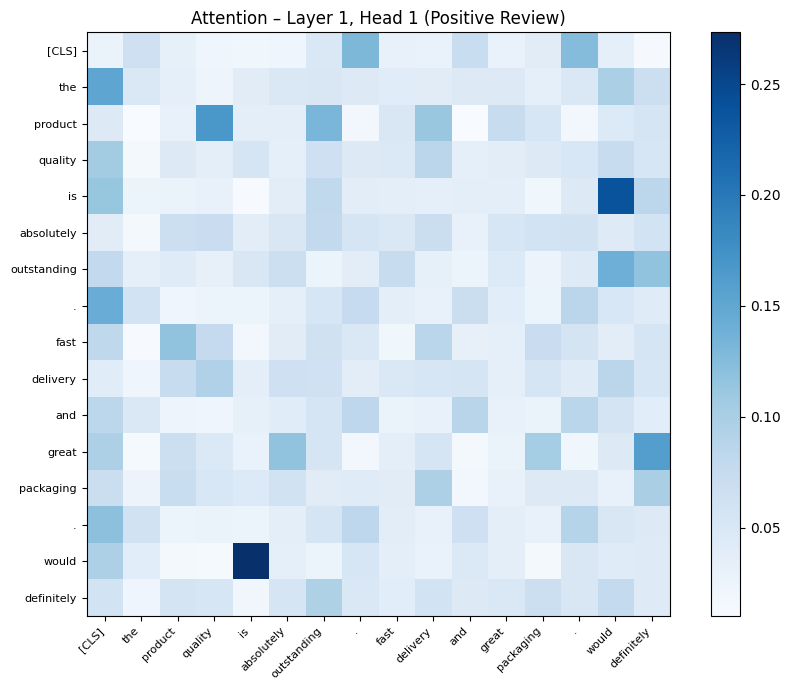

Layer 1: local/syntactic patterns. Tokens attend to their neighbours.


In [11]:
# Heatmap 1 — Layer 1, Head 1 (positive review)
pos_text = "The product quality is absolutely outstanding. Fast delivery and great packaging. Would definitely recommend."
tokens_p, attns_p = get_attentions(pos_text)

n = min(len(tokens_p), 16)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(attns_p[0, 0, :n, :n], cmap='Blues')
ax.set_xticks(range(n)); ax.set_xticklabels(tokens_p[:n], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(n)); ax.set_yticklabels(tokens_p[:n], fontsize=8)
ax.set_title('Attention – Layer 1, Head 1 (Positive Review)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('/kaggle/working/attn_layer1.png', dpi=120)
plt.show()
print('Layer 1: local/syntactic patterns. Tokens attend to their neighbours.')

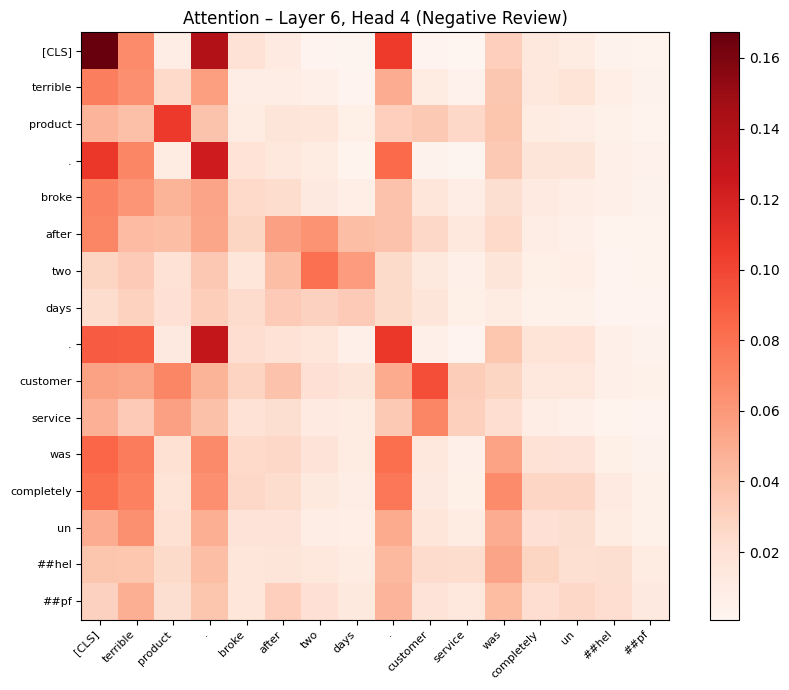

Final layer: [CLS] attends to sentiment words like terrible, waste, unhelpful.


In [12]:
# Heatmap 2 — Final layer, Head 4 (negative review)
neg_text = "Terrible product. Broke after two days. Customer service was completely unhelpful. Total waste of money."
tokens_n, attns_n = get_attentions(neg_text)

last = attns_n.shape[0] - 1
n = min(len(tokens_n), 16)
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(attns_n[last, 3, :n, :n], cmap='Reds')
ax.set_xticks(range(n)); ax.set_xticklabels(tokens_n[:n], rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(n)); ax.set_yticklabels(tokens_n[:n], fontsize=8)
ax.set_title(f'Attention – Layer {last+1}, Head 4 (Negative Review)')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('/kaggle/working/attn_layer6.png', dpi=120)
plt.show()
print('Final layer: [CLS] attends to sentiment words like terrible, waste, unhelpful.')

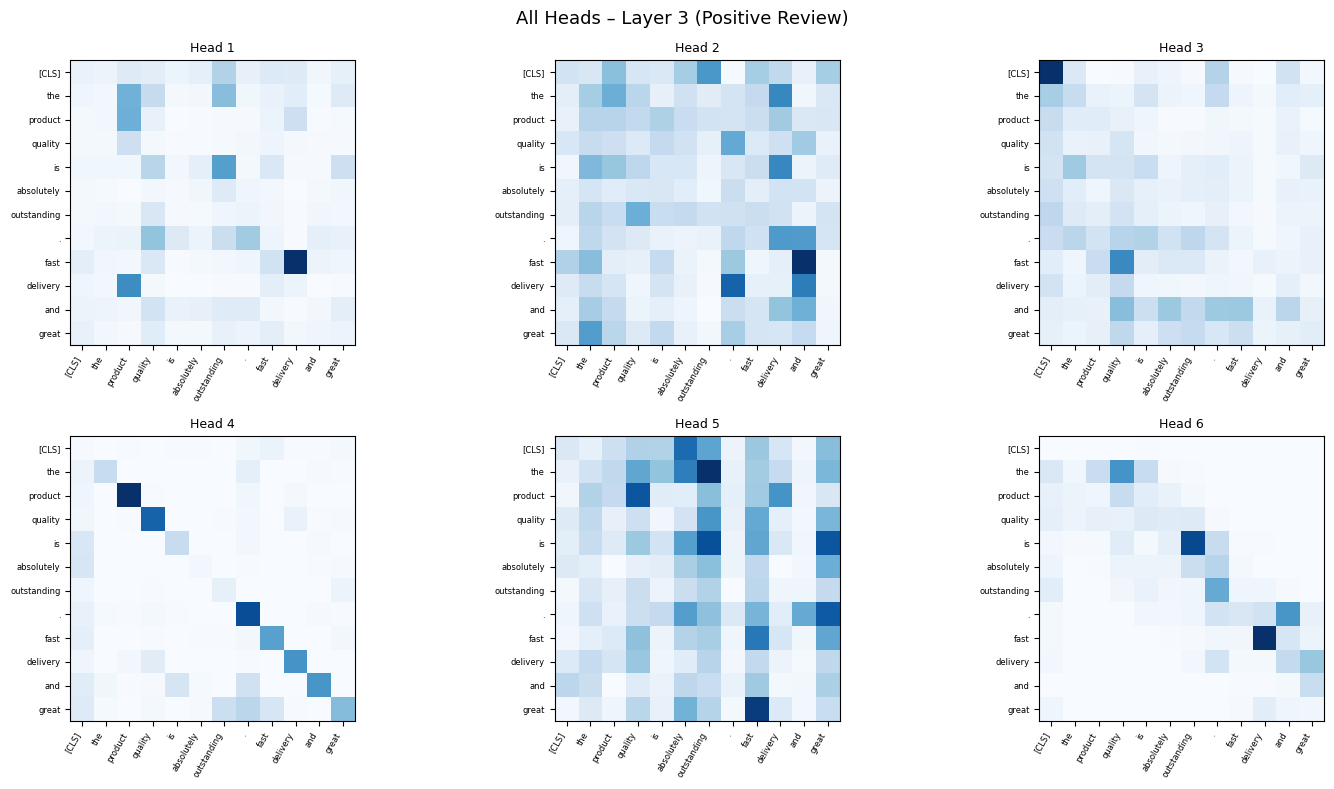

In [13]:
# All 6 heads in layer 3
n = min(len(tokens_p), 12)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('All Heads – Layer 3 (Positive Review)', fontsize=13)
for i, ax in enumerate(axes.flat):
    im = ax.imshow(attns_p[2, i, :n, :n], cmap='Blues')
    ax.set_title(f'Head {i+1}', fontsize=9)
    ax.set_xticks(range(n)); ax.set_xticklabels(tokens_p[:n], rotation=60, ha='right', fontsize=6)
    ax.set_yticks(range(n)); ax.set_yticklabels(tokens_p[:n], fontsize=6)
plt.tight_layout()
plt.savefig('/kaggle/working/attn_all_heads.png', dpi=120)
plt.show()

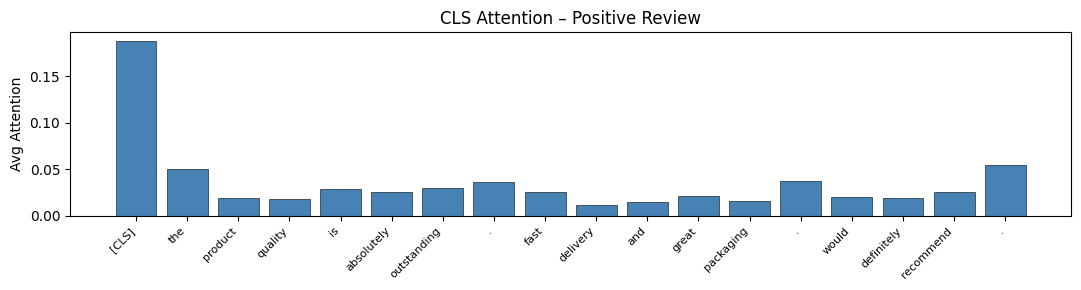

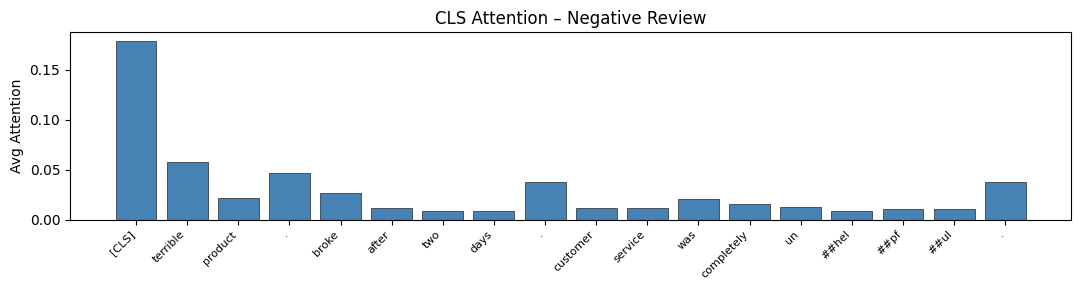

In [14]:
# CLS attention bar chart
def plot_cls(tokens, attns, title, fname):
    avg = attns[:, :, 0, :].mean(axis=(0, 1))
    n   = min(len(tokens), 18)
    fig, ax = plt.subplots(figsize=(11, 3))
    ax.bar(range(n), avg[:n], color='steelblue', edgecolor='black', linewidth=0.4)
    ax.set_xticks(range(n)); ax.set_xticklabels(tokens[:n], rotation=45, ha='right', fontsize=8)
    ax.set_title(title)
    ax.set_ylabel('Avg Attention')
    plt.tight_layout()
    plt.savefig(fname, dpi=120)
    plt.show()

plot_cls(tokens_p, attns_p, 'CLS Attention – Positive Review', '/kaggle/working/cls_pos.png')
plot_cls(tokens_n, attns_n, 'CLS Attention – Negative Review', '/kaggle/working/cls_neg.png')

# free attention model
del attn_model
gc.collect()
torch.cuda.empty_cache()

## 6. SHAP (20 samples)

In [21]:
clf = pipeline(
    "text-classification",
    model=SAVE_PATH,
    tokenizer=tokenizer,
    device=-1,
    top_k=None,          # IMPORTANT
    truncation=True,
    max_length=MAX_LEN
)



Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [23]:
test_df   = test_data.to_pandas()
neg_texts = test_df[test_df['label']==0]['text'].sample(10, random_state=42).tolist()
pos_texts = test_df[test_df['label']==1]['text'].sample(10, random_state=42).tolist()
shap_texts = [' '.join(t.split()[:60]) for t in neg_texts + pos_texts]

explainer = shap.Explainer(clf)
print('Running SHAP on 20 samples...')
t0 = time.time()
shap_vals = explainer(shap_texts)
shap_time = time.time() - t0
print(f'Done in {shap_time:.1f}s')

Running SHAP on 20 samples...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:   5%|▌         | 1/20 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  15%|█▌        | 3/20 [01:01<04:28, 15.79s/it]

...

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 20/20 [08:47<00:00, 26.98s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 21it [09:19, 27.98s/it]                        

Done in 559.5s


In [16]:
# text plots for one neg and one pos sample
shap.plots.text(shap_vals[0, :, 1])
shap.plots.text(shap_vals[10, :, 1])

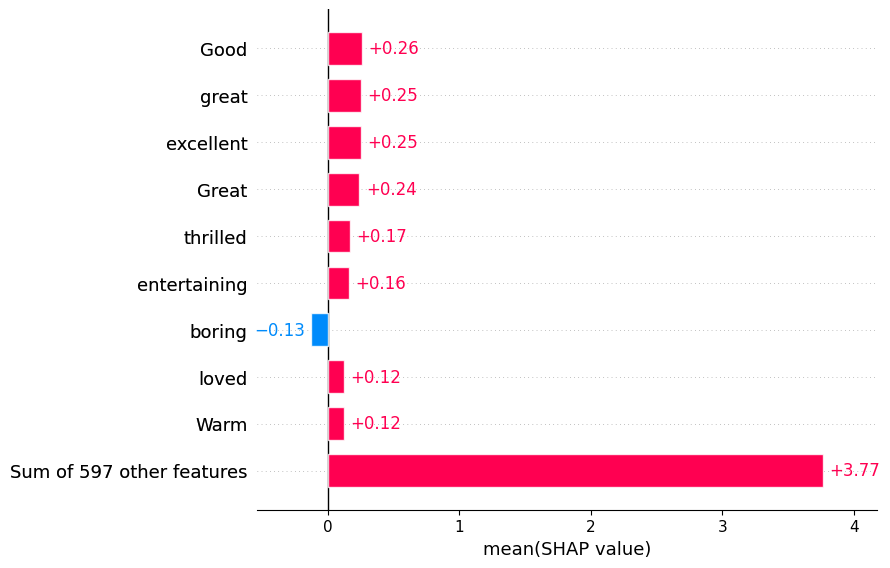

<Figure size 640x480 with 0 Axes>

In [17]:
# summary bar
shap.plots.bar(shap_vals[:, :, 1].mean(0))
plt.savefig('/kaggle/working/shap_summary.png', dpi=120, bbox_inches='tight')
plt.show()

In [18]:
# waterfall plots for all 20
for i in range(20):
    label = 'NEG' if i < 10 else 'POS'
    shap.plots.waterfall(shap_vals[i, :, 1], max_display=8, show=False)
    plt.title(f'SHAP – Sample {i+1} ({label})')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/shap_{i+1}.png', dpi=100, bbox_inches='tight')
    plt.close()
print('20 SHAP plots saved.')

20 SHAP plots saved.


## 7. LIME (20 samples)

In [22]:
def predict_fn(texts):
    out = clf(texts, batch_size=16)

    probs = []
    for r in out:
        r = sorted(r, key=lambda d: d["label"])
        probs.append([d["score"] for d in r])

    return np.array(probs)

lime_exp     = LimeTextExplainer(class_names=['NEGATIVE','POSITIVE'], random_state=42)
lime_results = []
lime_times   = []

for i, text in enumerate(shap_texts):
    label = 0 if i < 10 else 1
    t0  = time.time()
    exp = lime_exp.explain_instance(text, predict_fn, num_features=10, num_samples=300, labels=[label])
    lime_times.append(time.time() - t0)
    lime_results.append((exp, label))
    print(f'{i+1}/20 done ({lime_times[-1]:.1f}s)')

print(f'Avg: {sum(lime_times)/20:.1f}s/sample')

1/20 done (14.5s)
2/20 done (11.9s)
3/20 done (3.8s)
4/20 done (9.6s)
5/20 done (9.8s)
6/20 done (9.0s)
7/20 done (8.9s)
8/20 done (10.2s)
9/20 done (9.5s)
10/20 done (6.6s)
11/20 done (3.7s)
12/20 done (8.5s)
13/20 done (8.3s)
14/20 done (9.7s)
15/20 done (7.8s)
16/20 done (6.6s)
17/20 done (3.4s)
18/20 done (7.1s)
19/20 done (10.0s)
20/20 done (10.3s)
Avg: 8.4s/sample


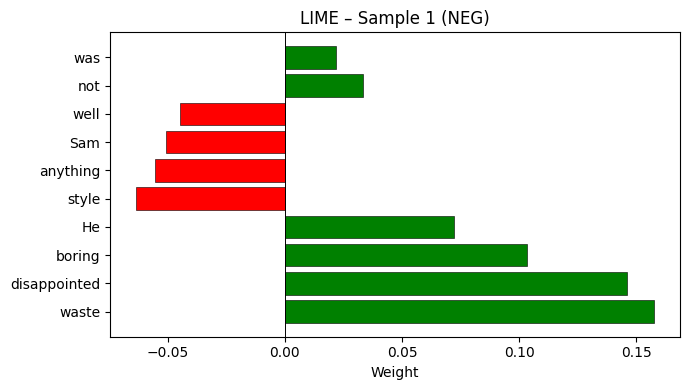

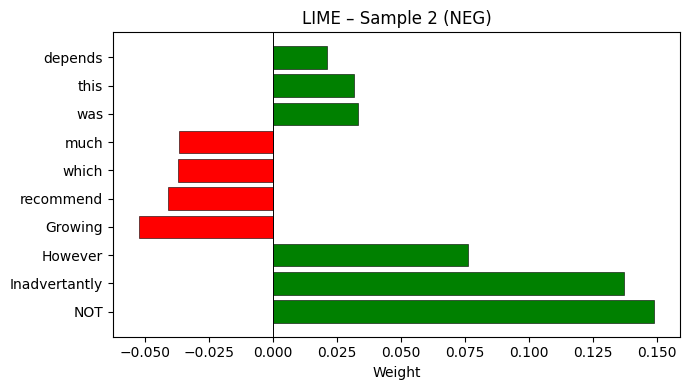

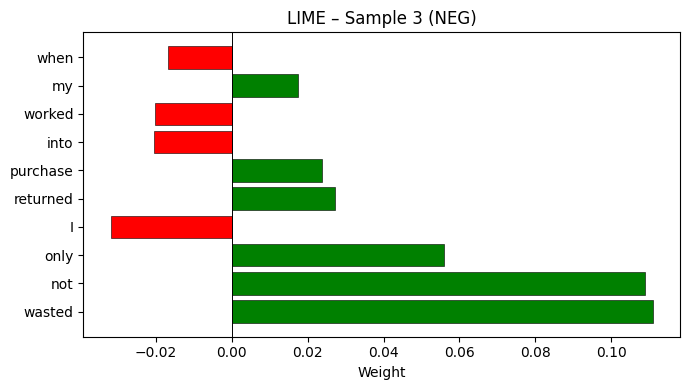

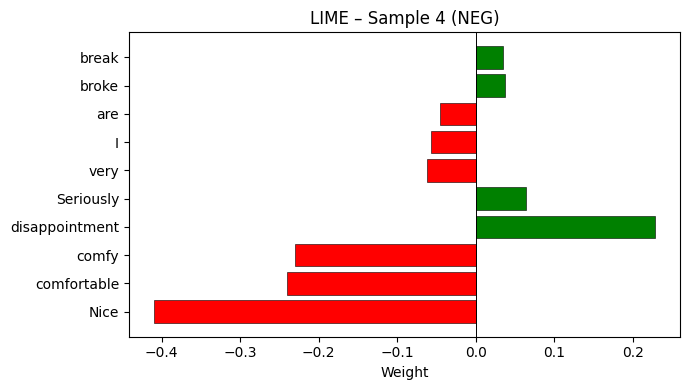

20 LIME plots saved.


In [24]:
# show first 4
for i in range(4):
    exp, label = lime_results[i]
    feats  = exp.as_list(label=label)
    words  = [f[0] for f in feats]
    scores = [f[1] for f in feats]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.barh(range(len(words)), scores,
            color=['green' if s > 0 else 'red' for s in scores],
            edgecolor='black', linewidth=0.4)
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(words)
    ax.axvline(0, color='black', linewidth=0.7)
    ax.set_title(f'LIME – Sample {i+1} ({"NEG" if label==0 else "POS"})')
    ax.set_xlabel('Weight')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/lime_{i+1}.png', dpi=120)
    plt.show()

# save all 20
for i, (exp, label) in enumerate(lime_results):
    fig = exp.as_pyplot_figure(label=label)
    fig.savefig(f'/kaggle/working/lime_all_{i+1}.png', dpi=100, bbox_inches='tight')
    plt.close()
print('20 LIME plots saved.')

## 8. SHAP vs LIME Comparison

In [26]:
# stability
e1 = lime_exp.explain_instance(shap_texts[0], predict_fn, num_features=10, num_samples=200, labels=[0])
e2 = lime_exp.explain_instance(shap_texts[0], predict_fn, num_features=10, num_samples=200, labels=[0])
f1s     = set(f[0] for f in e1.as_list(label=0))
f2s     = set(f[0] for f in e2.as_list(label=0))
jaccard = len(f1s & f2s) / len(f1s | f2s)
print(f'LIME stability (Jaccard): {jaccard:.3f}')
print('SHAP stability: 1.000 (deterministic)')

LIME stability (Jaccard): 0.250
SHAP stability: 1.000 (deterministic)


In [27]:
# faithfulness
orig = predict_fn([shap_texts[0]])[0][1]

def mask_words(text, words):
    return ' '.join(w for w in text.split() if w.lower() not in [x.lower() for x in words])

lime_top5 = [f[0] for f in lime_results[0][0].as_list(label=0)[:5]]
shap_top5 = [shap_vals[0,:,1].data[i] for i in np.argsort(np.abs(shap_vals[0,:,1].values))[-5:]]

lime_drop = abs(orig - predict_fn([mask_words(shap_texts[0], lime_top5)])[0][1])
shap_drop = abs(orig - predict_fn([mask_words(shap_texts[0], shap_top5)])[0][1])

print(f'Original P(pos): {orig:.4f}')
print(f'SHAP faithfulness (prob drop): {shap_drop:.4f}')
print(f'LIME faithfulness (prob drop): {lime_drop:.4f}')

Original P(pos): 0.0191
SHAP faithfulness (prob drop): 0.0000
LIME faithfulness (prob drop): 0.3247


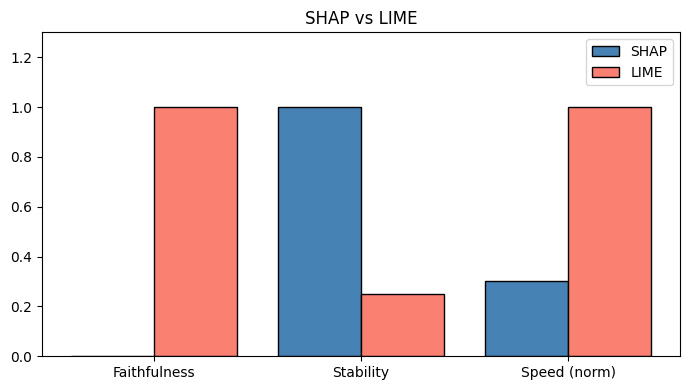

Runtime — SHAP: 28.0s/sample | LIME: 8.4s/sample


In [28]:
# comparison bar chart
s_vals = [shap_drop, 1.0,     1/(shap_time/20)]
l_vals = [lime_drop, jaccard, 1/(sum(lime_times)/20)]
mx     = [max(a, b) for a, b in zip(s_vals, l_vals)]
s_vals = [v/m for v, m in zip(s_vals, mx)]
l_vals = [v/m for v, m in zip(l_vals, mx)]

x = np.arange(3)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x-0.2, s_vals, 0.4, label='SHAP', color='steelblue', edgecolor='black')
ax.bar(x+0.2, l_vals, 0.4, label='LIME', color='salmon',    edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(['Faithfulness', 'Stability', 'Speed (norm)'])
ax.set_ylim(0, 1.3)
ax.legend()
ax.set_title('SHAP vs LIME')
plt.tight_layout()
plt.savefig('/kaggle/working/shap_vs_lime.png', dpi=120)
plt.show()

print(f'Runtime — SHAP: {shap_time/20:.1f}s/sample | LIME: {sum(lime_times)/20:.1f}s/sample')

## 9. Error Analysis

Errors: 73/1000 (7.3%)
False Positives: 37 | False Negatives: 36


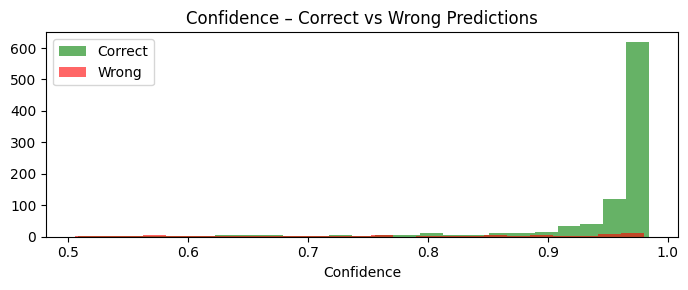

In [29]:
proba = torch.softmax(torch.tensor(logits), dim=-1).numpy()
test_df['pred'] = y_pred
test_df['true'] = y_true
test_df['conf'] = proba.max(axis=1)
test_df['ok']   = test_df['pred'] == test_df['true']

errors = test_df[~test_df['ok']]
fp = errors[errors['true']==0]
fn = errors[errors['true']==1]

print(f'Errors: {len(errors)}/{len(test_df)} ({len(errors)/len(test_df)*100:.1f}%)')
print(f'False Positives: {len(fp)} | False Negatives: {len(fn)}')

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(test_df[test_df['ok']]['conf'],  bins=25, alpha=0.6, label='Correct', color='green')
ax.hist(test_df[~test_df['ok']]['conf'], bins=25, alpha=0.6, label='Wrong',   color='red')
ax.set_xlabel('Confidence')
ax.set_title('Confidence – Correct vs Wrong Predictions')
ax.legend()
plt.tight_layout()
plt.savefig('/kaggle/working/error_conf.png', dpi=120)
plt.show()

In [30]:
print('Top 3 False Positives (neg predicted as pos):')
for _, r in fp.nlargest(3, 'conf').iterrows():
    print(f'  conf={r["conf"]:.2f} | {r["text"][:120]}')

print('\nTop 3 False Negatives (pos predicted as neg):')
for _, r in fn.nlargest(3, 'conf').iterrows():
    print(f'  conf={r["conf"]:.2f} | {r["text"][:120]}')

Top 3 False Positives (neg predicted as pos):
  conf=0.98 | Humorous, factual, and entertaining. As a former Carbon County resident who is familiar with all the people mentioned in
  conf=0.98 | Up to usual standards! The standards being excellent! This is a warm, witty, and charming example of mystery writing. Qu
  conf=0.98 | IT'S ABOUT TIME!!!!!! YEH!....... I really enjoyed this book because it not only gives you actual pictures of women arti

Top 3 False Negatives (pos predicted as neg):
  conf=0.98 | Not as good as the original When I saw this in theaters the weekend it opened, I was expecting to see a movie that was m
  conf=0.98 | Hard to trust a value brand, isn't it? In April 2003 (six months before this writing) I was dimly aware that I was runni
  conf=0.97 | Not Quite Happy Ever After... "Paul and Michelle",the sequel to "Friends" is set 3 years after the lovers last saw each 


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  25%|██▌       | 1/4 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  75%|███████▌  | 3/4 [00:56<00:14, 14.76s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|██████████| 4/4 [01:25<00:00, 20.96s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 5it [01:58, 29.62s/it]                       


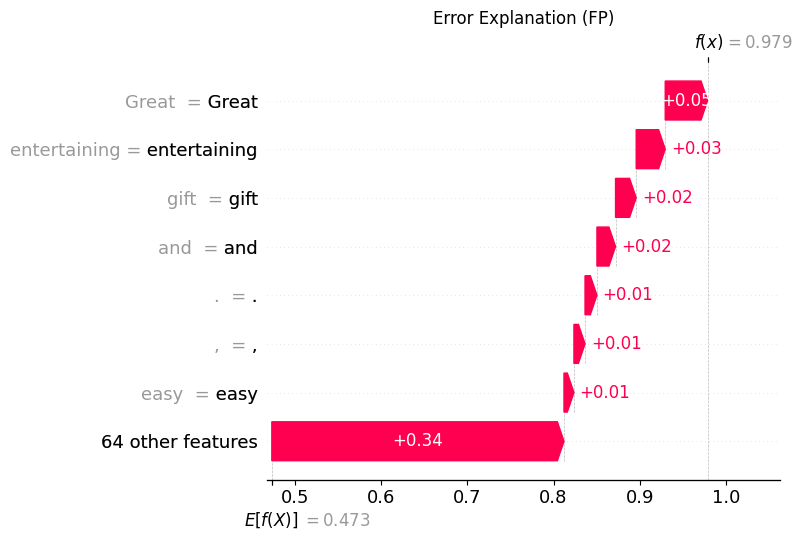

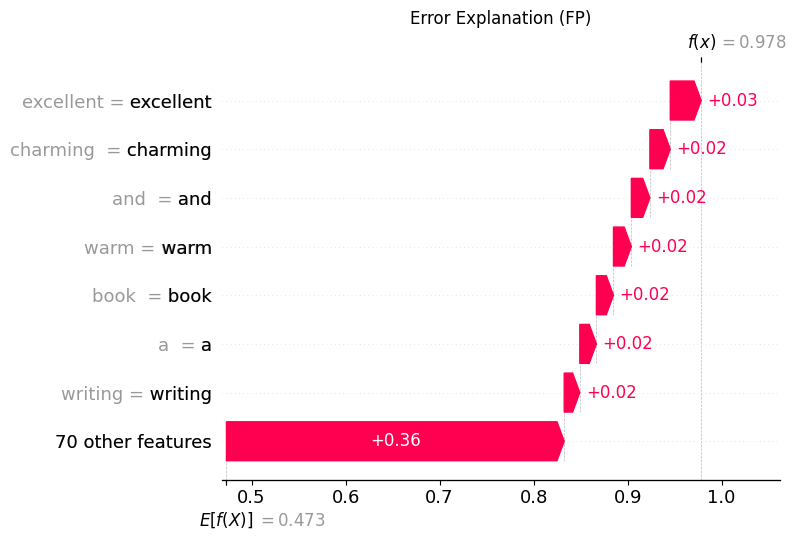

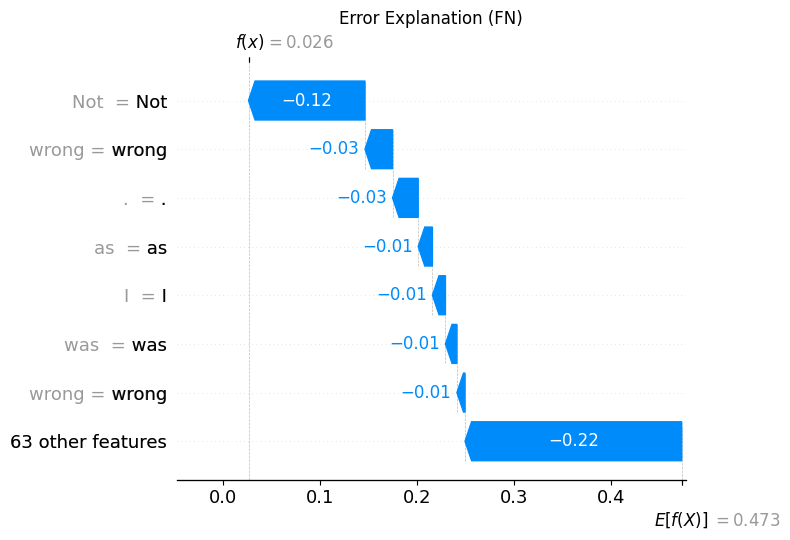

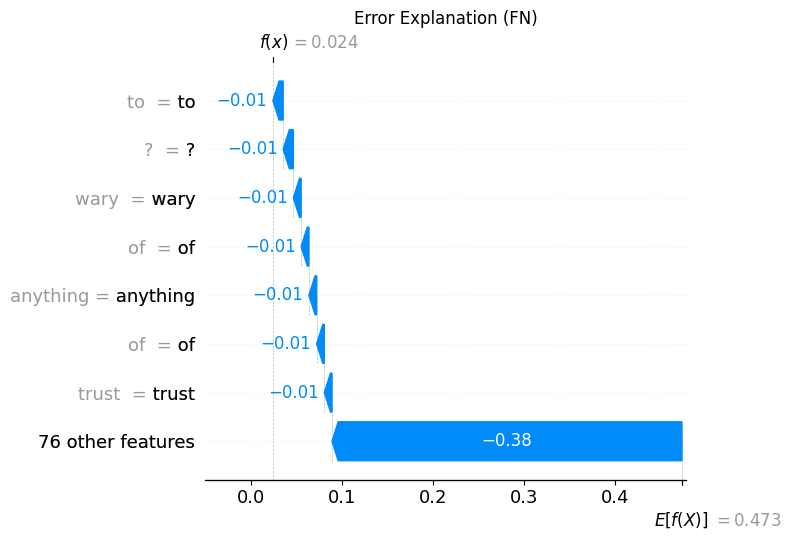

In [31]:
err_texts = (
    fp.nlargest(2, 'conf')['text'].tolist() +
    fn.nlargest(2, 'conf')['text'].tolist()
)
err_texts = [' '.join(t.split()[:60]) for t in err_texts]
err_shap  = explainer(err_texts)

for i, lbl in enumerate(['FP', 'FP', 'FN', 'FN']):
    shap.plots.waterfall(err_shap[i, :, 1], max_display=8, show=False)
    plt.title(f'Error Explanation ({lbl})')
    plt.tight_layout()
    plt.savefig(f'/kaggle/working/error_{lbl}_{i}.png', dpi=100, bbox_inches='tight')
    plt.show()

In [32]:
import platform, transformers, sklearn
print('Python:      ', platform.python_version())
print('PyTorch:     ', torch.__version__)
print('Transformers:', transformers.__version__)
print('Sklearn:     ', sklearn.__version__)
print('Device:      ', DEVICE)
if torch.cuda.is_available():
    print('GPU:         ', torch.cuda.get_device_name(0))
    print('VRAM used:   ', round(torch.cuda.memory_allocated()/1e9, 2), 'GB')

Python:       3.12.12
PyTorch:      2.10.0+cu128
Transformers: 5.0.0
Sklearn:      1.6.1
Device:       cuda
GPU:          Tesla T4
VRAM used:    0.84 GB
